In [2]:
import sys
print(sys.executable)

c:\Users\cesia\OneDrive\Escriptori\Adv_Buss_Analy\.venv\Scripts\python.exe


Dataset cargado correctamente.


C:\Users\cesia\AppData\Local\Temp\ipykernel_23972\2682610110.py:25: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_analysis['date'] = pd.to_datetime(df_analysis['date'])


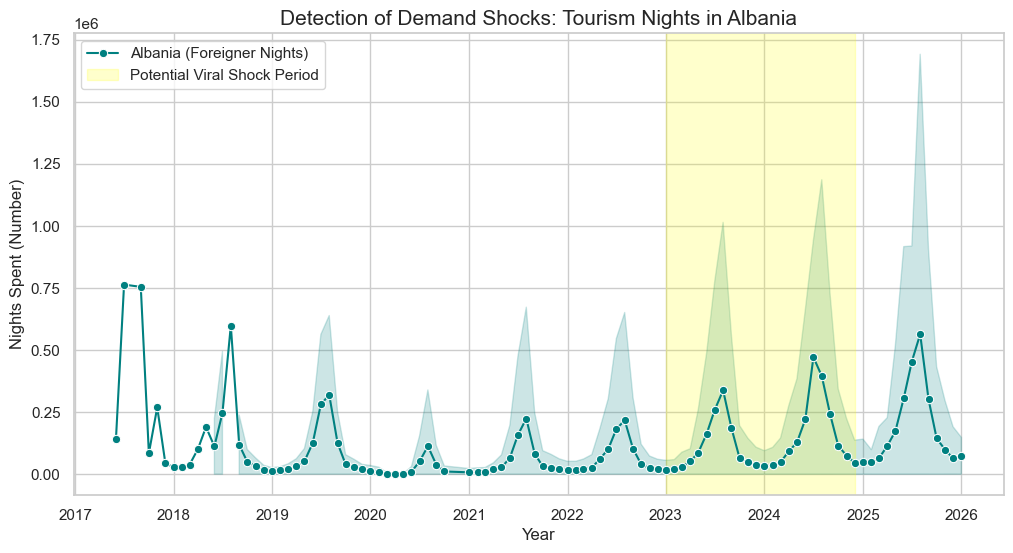

------------------------------
ANALYSIS OF RECENT GROWTH
Country: AL | Latest Month: 2026-01-01 | YoY Growth: -98.87%
Country: DK | Latest Month: 2026-01-01 | YoY Growth: -100.00%
Country: IT | Latest Month: 2026-01-01 | YoY Growth: -100.00%
Country: PT | Latest Month: 2026-01-01 | YoY Growth: -100.00%


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Cargar el dataset generado en el paso anterior
# Asegúrate de que el archivo .csv esté en la misma carpeta que este notebook
try:
    df = pd.read_csv('cleaned_tourism_data.csv')
    print("Dataset cargado correctamente.")
except FileNotFoundError:
    print("Error: No se encontró 'cleaned_tourism_data.csv'. Ejecuta primero el script de limpieza.")

# 3. Filtrado según los objetivos del proyecto (Fase 1: Data Pipeline) [cite: 47, 52]
# - nace_r2 == 'I551-I553': Suma de hoteles, apartamentos y campings (Impacto total)
# - c_resid == 'FOR': Turistas extranjeros (Clave para detectar viralidad internacional)
df_analysis = df[(df['nace_r2'] == 'I551-I553') & (df['c_resid'] == 'FOR')].copy()

# 4. Preparación de datos temporales
df_analysis = df_analysis.dropna(subset=['value'])
df_analysis['date'] = pd.to_datetime(df_analysis['date'])

# 5. Visualización de Casos de Estudio (Albania vs Otros) [cite: 30, 32]
# Creamos un gráfico para ver el crecimiento explosivo en Albania
plt.figure()
al_data = df_analysis[df_analysis['geo'] == 'AL']

if not al_data.empty:
    sns.lineplot(data=al_data, x='date', y='value', marker='o', color='teal', label='Albania (Foreigner Nights)')
    plt.title('Detection of Demand Shocks: Tourism Nights in Albania', fontsize=15)
    plt.ylabel('Nights Spent (Number)')
    plt.xlabel('Year')
    
    # Marcamos el periodo 2023-2024 donde mencionáis el +93% de crecimiento [cite: 6]
    plt.axvspan('2023-01-01', '2024-12-01', color='yellow', alpha=0.2, label='Potential Viral Shock Period')
    plt.legend()
    plt.show()
else:
    print("No hay datos suficientes para mostrar el gráfico de Albania.")

# 6. Cálculo de métricas de impacto para el One-Pager [cite: 6, 78]
print("-" * 30)
print("ANALYSIS OF RECENT GROWTH")
for country in df_analysis['geo'].unique():
    country_data = df_analysis[df_analysis['geo'] == country].sort_values('date')
    if len(country_data) > 12:
        latest = country_data.iloc[-1]
        # Buscamos el mismo mes del año anterior para calcular crecimiento real sin estacionalidad
        last_year_date = latest['date'] - pd.DateOffset(years=1)
        prev_year_val = country_data[country_data['date'] == last_year_date]['value']
        
        if not prev_year_val.empty:
            growth = ((latest['value'] - prev_year_val.values[0]) / prev_year_val.values[0]) * 100
            print(f"Country: {country} | Latest Month: {latest['date'].date()} | YoY Growth: {growth:.2f}%")

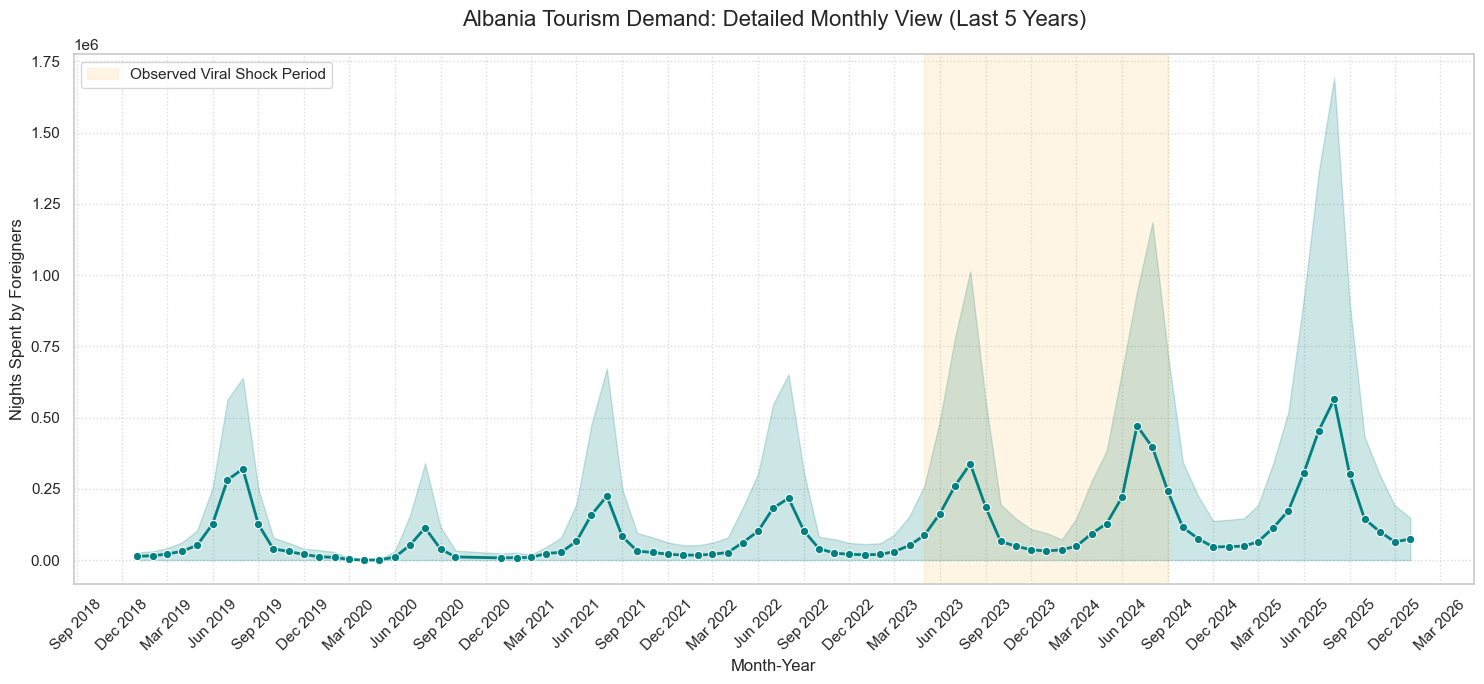

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Filtrado de datos (Asegúrate de haber corrido la celda anterior con df_analysis)
# Filtramos solo los últimos 5 años para ver el detalle de los meses
start_date = '2019-01-01'
al_data_5y = df_analysis[(df_analysis['geo'] == 'AL') & (df_analysis['date'] >= start_date)].copy()

if not al_data_5y.empty:
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # 2. Plot principal
    sns.lineplot(data=al_data_5y, x='date', y='value', marker='o', color='teal', linewidth=2, ax=ax)
    
    # 3. Configuración detallada del eje X (Meses)
    # Mostramos una etiqueta cada 3 meses para que sea legible
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    
    # Rotamos las etiquetas para que no se solapen
    plt.xticks(rotation=45)
    
    # 4. Estética y etiquetas
    plt.title('Albania Tourism Demand: Detailed Monthly View (Last 5 Years)', fontsize=16, pad=20)
    plt.ylabel('Nights Spent by Foreigners', fontsize=12)
    plt.xlabel('Month-Year', fontsize=12)
    
    # Resaltamos el "Shock" de 2023-2024 que mencionáis en el One-pager
    plt.axvspan('2023-05-01', '2024-09-01', color='orange', alpha=0.1, label='Observed Viral Shock Period')
    
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos de Albania para el periodo seleccionado (2019-2024).")

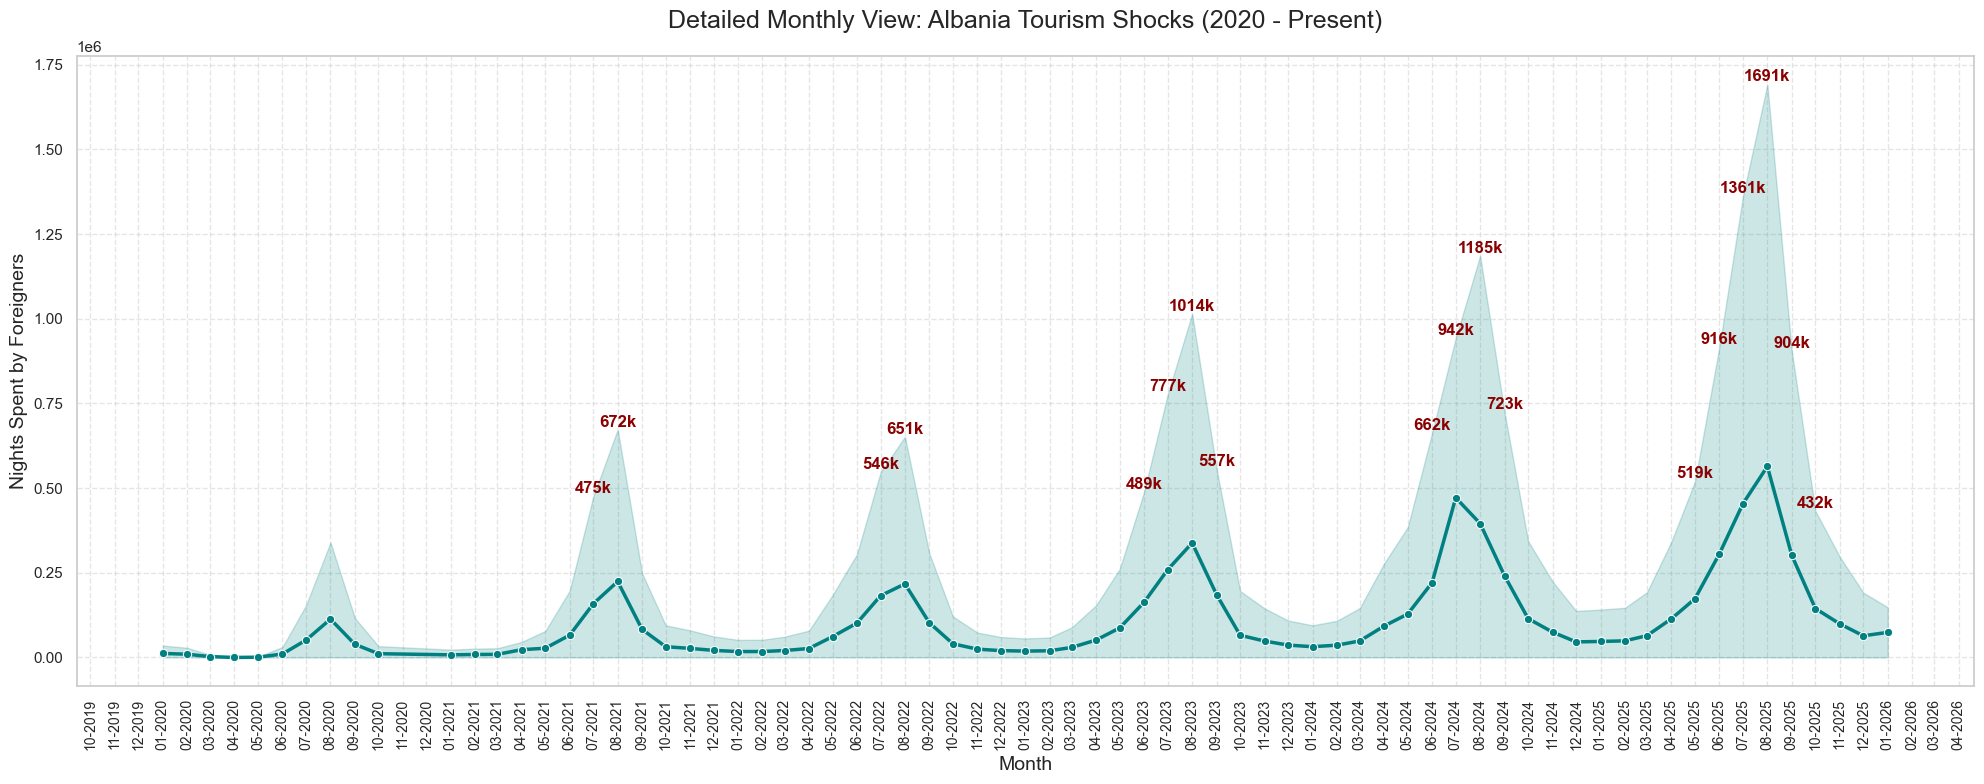

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. Filtramos desde enero de 2020 hasta el final
start_date = '2020-01-01'
al_data_recent = df_analysis[(df_analysis['geo'] == 'AL') & (df_analysis['date'] >= start_date)].copy()

if not al_data_recent.empty:
    # Hacemos el gráfico bastante ancho (20 pulgadas) para que quepan todos los meses
    fig, ax = plt.subplots(figsize=(20, 8))
    
    # 2. Dibujamos la línea y los puntos
    sns.lineplot(data=al_data_recent, x='date', y='value', marker='o', color='teal', linewidth=2.5, ax=ax)
    
    # 3. CONFIGURACIÓN DEL EJE X PARA VER TODOS LOS MESES
    # 'interval=1' fuerza a que aparezca CADA mes
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
    
    # Rotación vertical para que no se solapen las fechas
    plt.xticks(rotation=90, fontsize=10)
    
    # 4. Estética
    plt.title('Detailed Monthly View: Albania Tourism Shocks (2020 - Present)', fontsize=18, pad=20)
    plt.ylabel('Nights Spent by Foreigners', fontsize=14)
    plt.xlabel('Month', fontsize=14)
    
    # Añadimos etiquetas de valor sobre los puntos más altos para ver el "shock"
    # Solo para los valores que superan un umbral (ej. 400.000)
    for x, y in zip(al_data_recent['date'], al_data_recent['value']):
        if y > 400000:
            ax.text(x, y, f'{int(y/1000)}k', color='darkred', fontweight='bold', ha='center', va='bottom')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("No hay datos disponibles para Albania desde 2020.")
    

C:\Users\cesia\AppData\Local\Temp\ipykernel_23972\3647232866.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])


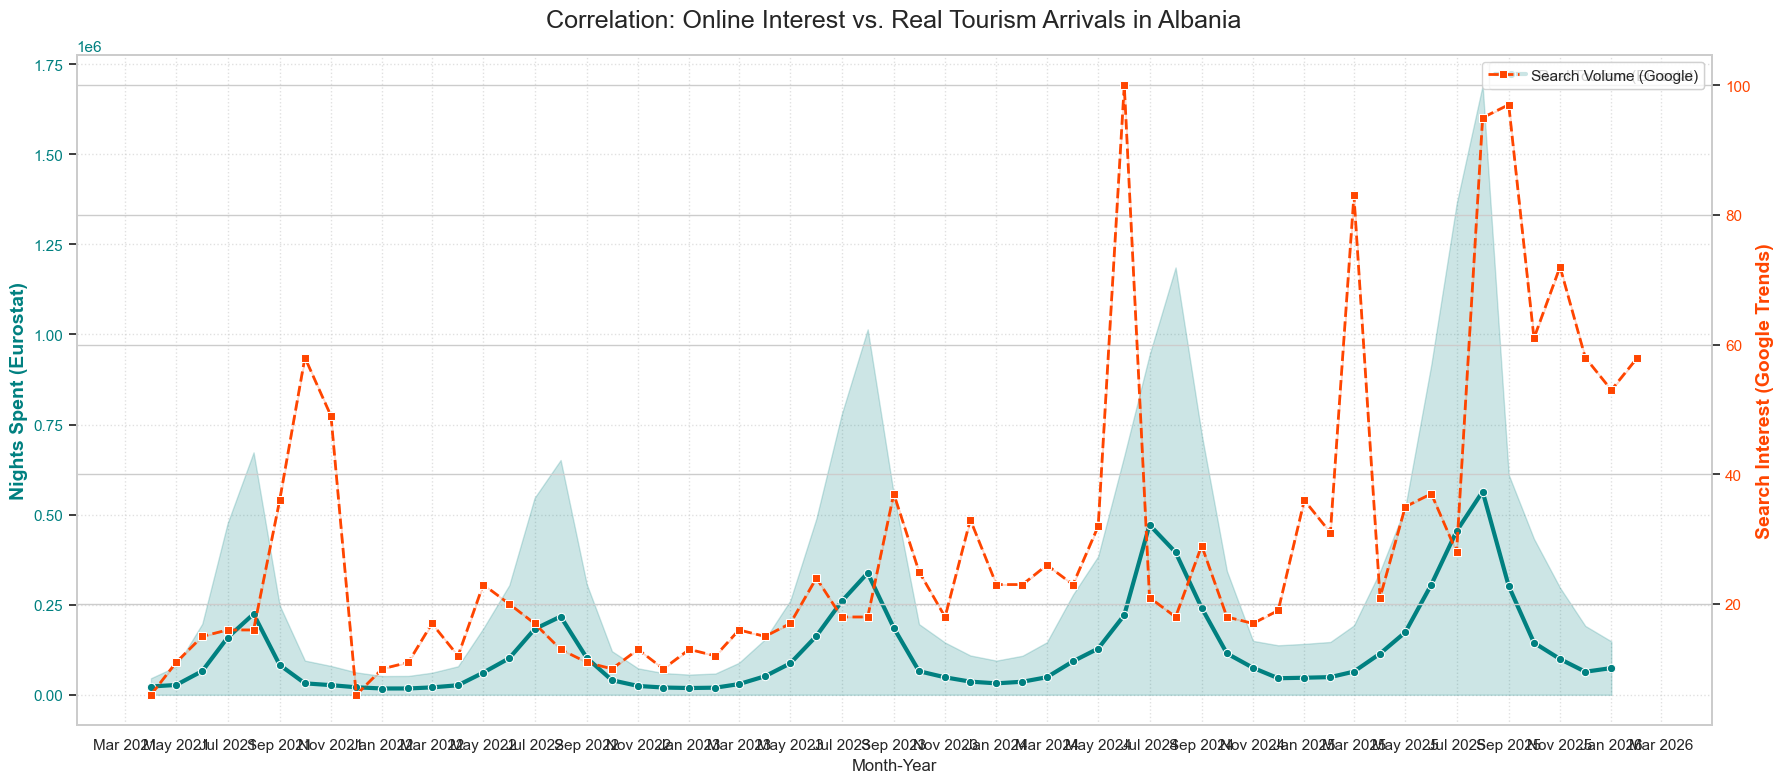

Coeficiente de Correlación de Pearson: 0.16


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. CARGAR Y PREPARAR DATOS DE EUROSTAT (Turismo Real)
df_eurostat = pd.read_csv('cleaned_tourism_data.csv')
df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])

# Filtramos Albania, Extranjeros, Total alojamientos desde 2020
al_real = df_eurostat[
    (df_eurostat['geo'] == 'AL') & 
    (df_eurostat['c_resid'] == 'FOR') & 
    (df_eurostat['nace_r2'] == 'I551-I553') & 
    (df_eurostat['date'] >= '2020-01-01')
].copy()

# 2. CARGAR Y PREPARAR DATOS DE GOOGLE TRENDS
# Asumo que el archivo se llama 'google_trends.csv'. Ajusta el nombre si es necesario.
# El parámetro skiprows=1 ayuda si el archivo de Google tiene una línea extra de info arriba
try:
    df_trends = pd.read_csv('time_series_Worldwide.csv') # Cambia el nombre si es distinto
    
    # Renombrar columnas para quitar comillas y espacios
    df_trends.columns = ['date', 'search_volume']
    df_trends['date'] = pd.to_datetime(df_trends['date'])
    
    # IMPORTANTE: Como Google da datos semanales, los agrupamos por mes para que coincidan con Eurostat
    df_trends_monthly = df_trends.resample('MS', on='date').mean().reset_index()
    
    # 3. UNIR AMBOS DATASETS (Merge)
    # Unimos por la fecha para asegurar que los puntos coincidan exactamente
    df_combined = pd.merge(al_real, df_trends_monthly, on='date', how='inner')

    # 4. CREAR EL PLOT DE CORRELACIÓN (Doble Eje Y)
    fig, ax1 = plt.subplots(figsize=(18, 8))

    # Eje Izquierdo: Eurostat (Pernoctaciones Reales)
    color_real = 'teal'
    ax1.set_xlabel('Month-Year', fontsize=12)
    ax1.set_ylabel('Nights Spent (Eurostat)', color=color_real, fontsize=14, fontweight='bold')
    sns.lineplot(data=df_combined, x='date', y='value', color=color_real, marker='o', linewidth=3, ax=ax1, label='Real Tourism (Eurostat)')
    ax1.tick_params(axis='y', labelcolor=color_real)

    # Crear el segundo eje para Google Trends
    ax2 = ax1.twinx() 
    color_trends = 'orangered'
    ax2.set_ylabel('Search Interest (Google Trends)', color=color_trends, fontsize=14, fontweight='bold')
    sns.lineplot(data=df_combined, x='date', y='search_volume', color=color_trends, marker='s', linestyle='--', linewidth=2, ax=ax2, label='Search Volume (Google)')
    ax2.tick_params(axis='y', labelcolor=color_trends)

    # 5. CONFIGURACIÓN DEL EJE X
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)

    plt.title('Correlation: Online Interest vs. Real Tourism Arrivals in Albania', fontsize=18, pad=20)
    ax1.grid(True, linestyle=':', alpha=0.6)
    
    fig.tight_layout()
    plt.show()

    # Cálculo de Correlación Matemática
    correlation = df_combined['value'].corr(df_combined['search_volume'])
    print(f"Coeficiente de Correlación de Pearson: {correlation:.2f}")

except Exception as e:
    print(f"Error al procesar Google Trends: {e}")
    print("Asegúrate de que el archivo 'google_trends.csv' esté en la carpeta y tenga las columnas 'Time' y 'tickets Albania'")

C:\Users\cesia\AppData\Local\Temp\ipykernel_23972\2648472402.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])


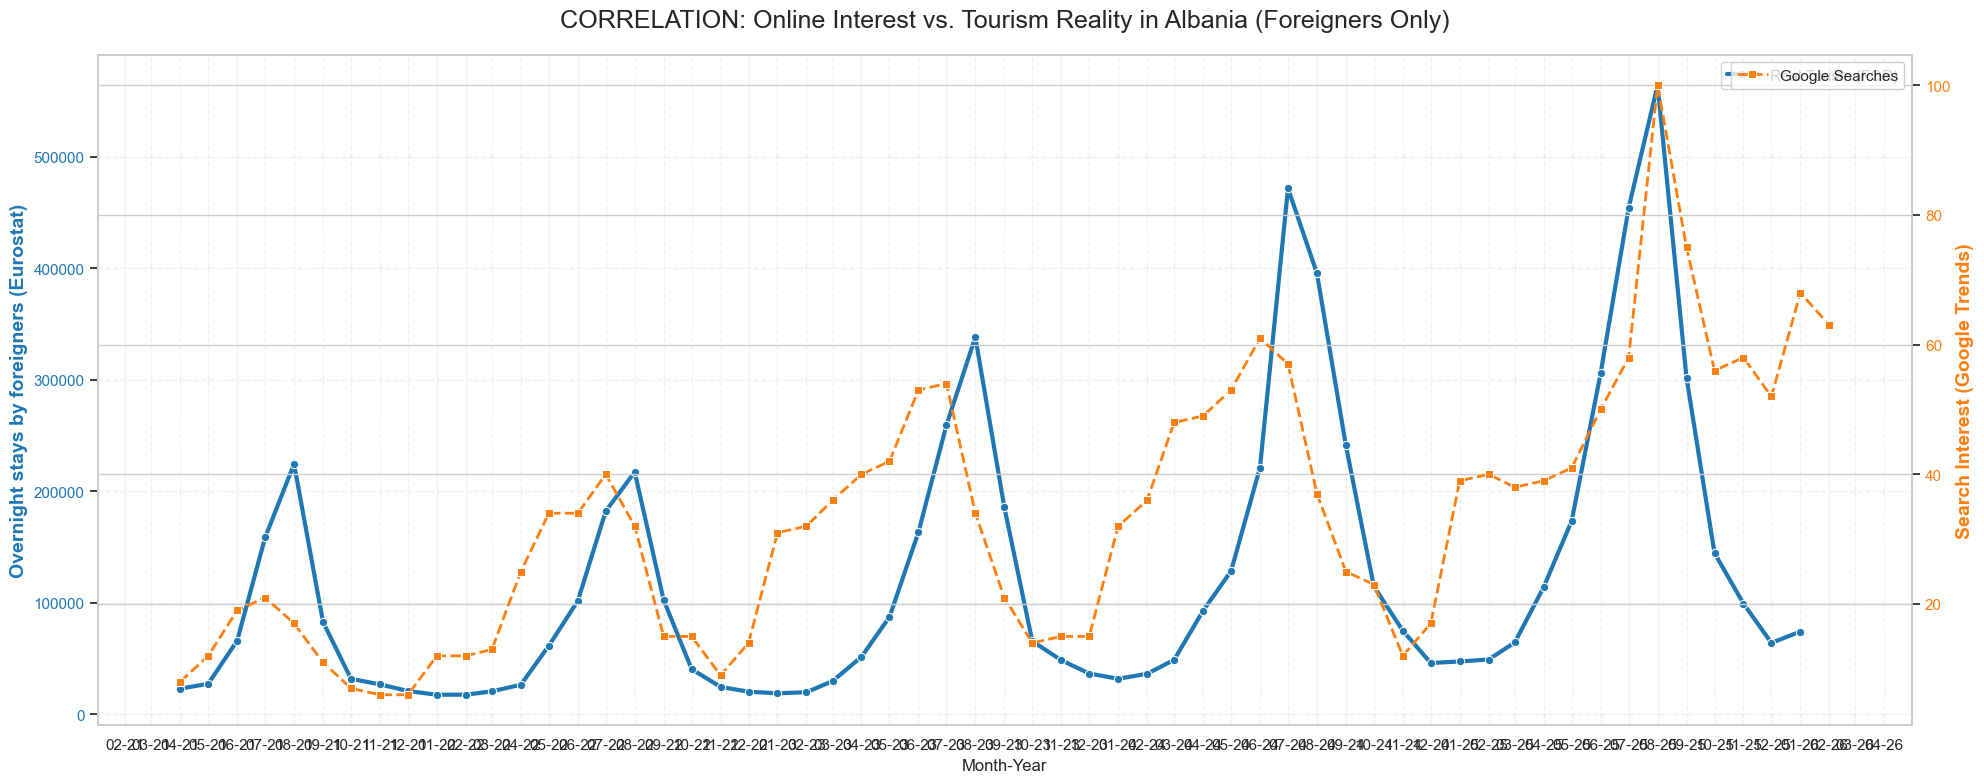


Correlation Coefficient between Searches and Overnight Stays: 0.28


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# 1. CARGAR Y PREPARAR DATOS DE EUROSTAT
df_eurostat = pd.read_csv('cleaned_tourism_data.csv')
df_eurostat['date'] = pd.to_datetime(df_eurostat['date'])

# FILTRO CRÍTICO: Solo Albania, solo Extranjeros (FOR), solo Total alojamientos (I551-I553)
al_real = df_eurostat[
    (df_eurostat['geo'] == 'AL') & 
    (df_eurostat['c_resid'] == 'FOR') & 
    (df_eurostat['nace_r2'] == 'I551-I553') & 
    (df_eurostat['date'] >= '2020-01-01')
].copy()

# 2. CARGAR Y PREPARAR DATOS DE GOOGLE TRENDS
try:
    df_trends = pd.read_csv('time_series_Worldwide4.csv') # Asegúrate de que el nombre sea correcto
    df_trends.columns = ['date', 'search_volume']
    df_trends['date'] = pd.to_datetime(df_trends['date'])
    
    # Agrupamos por mes para que coincida con Eurostat
    df_trends_monthly = df_trends.resample('MS', on='date').mean().reset_index()
    
    # 3. UNIR AMBOS DATASETS
    df_combined = pd.merge(al_real, df_trends_monthly, on='date', how='inner')

    # 4. CREAR EL PLOT DE CORRELACIÓN SIN SOMBRAS
    fig, ax1 = plt.subplots(figsize=(20, 8))

    # Línea Eurostat (Eje Izquierdo) - Usamos errorbar=None para línea limpia
    color_real = '#1f77b4' # Azul profesional
    ax1.set_xlabel('Month-Year', fontsize=12)
    ax1.set_ylabel('Overnight stays by foreigners (Eurostat)', color=color_real, fontsize=14, fontweight='bold')
    sns.lineplot(data=df_combined, x='date', y='value', color=color_real, 
                 marker='o', linewidth=3, ax=ax1, label='Real Turism (FOR)', errorbar=None)
    ax1.tick_params(axis='y', labelcolor=color_real)

    # Línea Google Trends (Eje Derecho)
    ax2 = ax1.twinx() 
    color_trends = '#ff7f0e' # Naranja Google
    ax2.set_ylabel('Search Interest (Google Trends)', color=color_trends, fontsize=14, fontweight='bold')
    sns.lineplot(data=df_combined, x='date', y='search_volume', color=color_trends, 
                 marker='s', linestyle='--', linewidth=2, ax=ax2, label='Google Searches', errorbar=None)
    ax2.tick_params(axis='y', labelcolor=color_trends)

    # 5. CONFIGURACIÓN EJE X (Todos los meses visibles)
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%y'))
    plt.xticks(rotation=90)

    plt.title('CORRELATION: Online Interest vs. Tourism Reality in Albania (Foreigners Only)', fontsize=18, pad=20)
    ax1.grid(True, linestyle='--', alpha=0.3)
    
    fig.tight_layout()
    plt.show()

    # Cálculo de Correlación
    correlation = df_combined['value'].corr(df_combined['search_volume'])
    print(f"\nCorrelation Coefficient between Searches and Overnight Stays: {correlation:.2f}")

except Exception as e:
    print(f"Error: {e}")

In [9]:
# Probamos desfases de 1 a 4 meses
for i in range(1, 5):
    lag_corr = df_combined['value'].corr(df_combined['search_volume'].shift(i))
    print(f"Correlación con un desfase de {i} mes(es): {lag_corr:.3f}")

Correlación con un desfase de 1 mes(es): 0.279
Correlación con un desfase de 2 mes(es): 0.290
Correlación con un desfase de 3 mes(es): 0.294
Correlación con un desfase de 4 mes(es): 0.243


In [10]:
# 1. Calcular la 'Anomalía'
# Comparamos el valor real contra la media móvil de los últimos 3 años para ese mismo mes
df_combined['rolling_mean'] = df_combined['value'].rolling(window=12).mean()
df_combined['deviation'] = df_combined['value'] - df_combined['rolling_mean']

# 2. Identificar meses de "Shock" (donde la desviación es muy alta)
shocks = df_combined[df_combined['deviation'] > df_combined['deviation'].std() * 1.5]

print("Meses detectados como 'Shocks de Demanda' en Albania:")
print(shocks[['date', 'value', 'deviation']])

Meses detectados como 'Shocks de Demanda' en Albania:
          date      value     deviation
45  2022-07-01   546313.0  4.534661e+05
48  2022-08-01   651445.0  5.109099e+05
78  2023-06-01   489107.0  4.062854e+05
81  2023-07-01   777320.0  6.371063e+05
84  2023-08-01  1014164.0  8.022782e+05
114 2024-06-01   662924.0  5.402346e+05
117 2024-07-01   942930.0  7.538175e+05
147 2025-05-01   519535.0  4.193811e+05
150 2025-06-01   916719.0  7.523883e+05
153 2025-07-01  1361672.0  1.099914e+06
156 2025-08-01  1691553.0  1.317314e+06
159 2025-09-01   904682.0  4.983689e+05


In [11]:
# Crear etiquetas de alerta basadas en la desviación
df_combined['alert_level'] = 'Green'
df_combined.loc[df_combined['deviation'] > df_combined['deviation'].std() * 1.0, 'alert_level'] = 'Amber'
df_combined.loc[df_combined['deviation'] > df_combined['deviation'].std() * 1.5, 'alert_level'] = 'Red'

# Ver cuántas alertas rojas hemos tenido
print(df_combined['alert_level'].value_counts())

alert_level
Green    161
Red       12
Amber      4
Name: count, dtype: int64
